# Cooling Coffee

**Category:** Data Visualization  
**Dataset:** hot-coffee.csv — 11 rows, 4 columns (wide format)  
**Objective:** Determine whether insulated mugs keep coffee hot longer,
and how much a lid specifically adds, communicated through well-crafted charts.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/hot-coffee.csv')
df

,time,insulated with lid,insulated,ceramic
0,5,146.6,135.5,128.8
1,10,141.0,118.9,113.9
2,15,136.7,107.9,102.5
3,20,132.5,100.5,95.9
4,25,129.0,94.6,90.5
5,30,125.6,90.8,86.3
6,35,123.4,87.6,83.6
7,40,121.6,85.4,81.6
8,45,118.5,82.9,79.8
9,50,117.6,81.3,78.2


## 1. Dataset Exploration

This section examines the dataset structure, data types, and missing values before beginning the analysis.

In [3]:
print("Shape: ", df.shape)
print()
print("Datatype: ")
print(df.dtypes)
print()
print("Missing Values: ")
print(df.isnull().sum())

Shape:  (11, 4)

Datatype: 
time                    int64
insulated with lid    float64
insulated             float64
ceramic               float64
dtype: object

Missing Values: 
time                  0
insulated with lid    0
insulated             0
ceramic               0
dtype: int64


## 2. Initial Visualization

Creating a basic line chart to establish a starting point before improving its clarity and presentation.

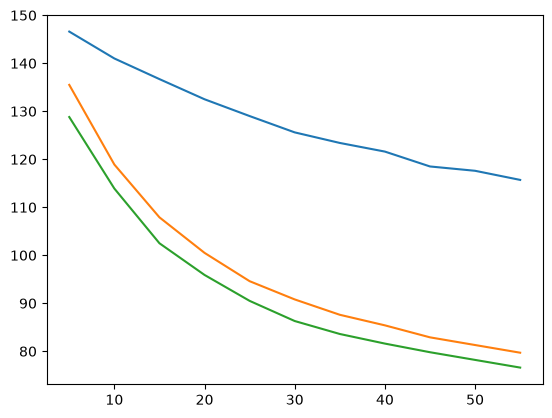

In [4]:
plt.plot(df['time'], df['insulated with lid'])
plt.plot(df['time'], df['insulated'])
plt.plot(df['time'], df['ceramic'])
plt.show()

## 3. Improving the Visualization

The chart is refined by adding informative labels, a legend, and a reference line for ambient room temperature to improve readability and interpretation.

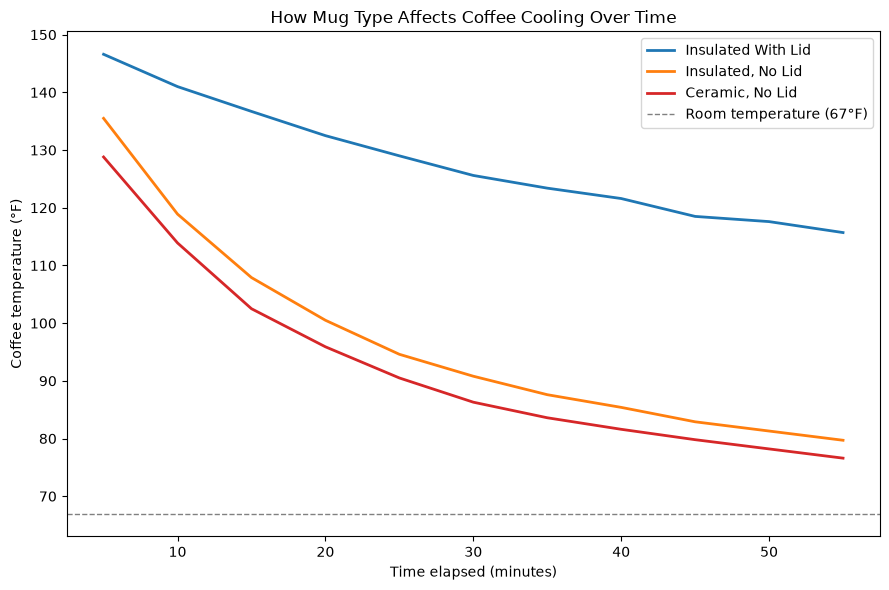

Chart Saved.


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    df['time'], 
    df['insulated with lid'], 
    label='Insulated With Lid', 
    color='C0', 
    linewidth=2
)
ax.plot(
    df['time'], 
    df['insulated'], 
    label='Insulated, No Lid', 
    color='C1', 
    linewidth=2
)
ax.plot(
    df['time'], 
    df['ceramic'], 
    label='Ceramic, No Lid', 
    color='C3', 
    linewidth=2
)

# Adding reference line
ax.axhline(
    y=67, 
    color='gray', 
    linestyle='--', 
    linewidth=1, 
    label='Room temperature (67°F)'
)

ax.set_xlabel('Time elapsed (minutes)')
ax.set_ylabel('Coffee temperature (°F)')
ax.set_title('How Mug Type Affects Coffee Cooling Over Time')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../images/plots/mug_type_coffee_cooling.png')
plt.show()

print("Chart Saved.")


## 4. Direct Line Labeling

Replacing the legend with direct labels at the end of each line to improve readability.

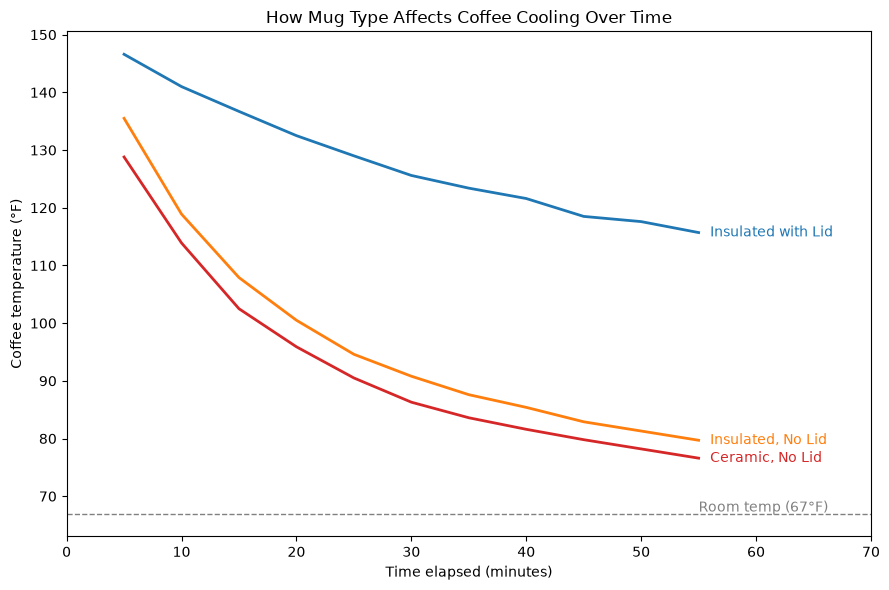

Chart Saved.


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

lines = {
    'Insulated with Lid' : ('insulated with lid', 'C0'),
    'Insulated, No Lid' : ('insulated', 'C1'),
    'Ceramic, No Lid' : ('ceramic', 'C3')
}

for label, (col, color) in lines.items():
    ax.plot(df['time'], df[col], color=color, linewidth=2)
    final_x = df['time'].iloc[-1]
    final_y = df[col].iloc[-1]
    ax.text(final_x + 1, final_y, label, color=color, va='center', fontsize=10)

ax.axhline(y=67, color='gray', linestyle='--', linewidth=1)
ax.text(
    df['time'].iloc[-1], 
    68, 
    'Room temp (67°F)', 
    color='gray', 
    va='center', 
    fontsize=10
)
ax.set_xlabel('Time elapsed (minutes)')
ax.set_ylabel('Coffee temperature (°F)')
ax.set_title('How Mug Type Affects Coffee Cooling Over Time')
ax.set_xlim(0, 70)

plt.tight_layout()

plt.savefig('../images/plots/cooling_curves_end_labeled.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 5. Quantifying the Results

Summarizing the cooling performance of each mug type using the final recorded temperatures.

In [15]:
final_row = df.iloc[-1]

print(f"After 55 minutes:")
print(f"  Insulated with lid: {final_row['insulated with lid']}°F")
print(f"  Insulated, no lid: {final_row['insulated']}°F")
print(f"  Ceramic, no lid: {final_row['ceramic']}°F")

lid_advantage = final_row['insulated with lid'] - final_row['insulated']
insulation_advantage = final_row['insulated'] - final_row['ceramic']

print(f"\nLid advantage at 55 min: {lid_advantage:.1f}°F warmer than insulated-no-lid.")
print(f"Insulation advantage at 55 min: {insulation_advantage:.1f}°F warmer than ceramic.")

After 55 minutes:
  Insulated with lid: 115.7°F
  Insulated, no lid: 79.7°F
  Ceramic, no lid: 76.6°F

Lid advantage at 55 min: 36.0°F warmer than insulated-no-lid.
Insulation advantage at 55 min: 3.1°F warmer than ceramic.
